## TenSolver

[TenSolver](https://github.com/SECQUOIA/TenSolver.jl) is a quantum-inspired optimization algorithm that solves Quadratic Unconstrained Binary Optimization (QUBO) problems. We will briefly go over the mechanism behind the algorithm.

### QUBO

A QUBO is a problem of the form
$$
\min_{x \in \mathbb{B}^N} \:  x^\top Q x \: = \: \min_{x \in \mathbb{B}^N} \: \sum_{i \ge j} Q_{ij} x_i x_j 
$$

where $Q \in \mathbb{R}^{N \times N}$ is a real matrix, $x$ is the vector of binary decision variables, and we write $\mathbb{B} = \{0,\,1\}$.

### Hamiltonian Equivalence

A QUBO problem can be reformulated as an eigenvalue problem by mapping it to a quantum many-body system.
In this reformulation, each binary variable $x_i$ is treated as a particle or a "site".
The binary values the variables can assume correspond to the basis states of a qubit.

We can then construct a Hamiltonian by replacing the binary variables with single-site operators $D_i$ ($2 \times 2$ diagonal matrices). In the new format, solving the QUBO amounts to finding the ground state of the corresponding Hamiltonian [1].
This reformulates a discrete optimization problem over binary variables as a continuous problem over complex variables.

Despite this reformulation, the problem is still solved entirely on classical hardware.
We use tensors to represent both the Hamiltonian and the system states.
The issue is that those tensors are extremely large and difficult to work with. 
The resulting Hamiltonian is a $2^N \times 2^N$ matrix.

### Tensor Networks

Thankfully, we can use a mathematical tool called Tensor Network (TN) to compress these large tensors into a more manageable form.
These objects consist of products or contractions between tensors of different ranks (dimensions).
With this tool, the operators (QUBO Hamiltonians) are represented as Matrix Product Operators (MPOs), products of rank-4 tensors, while the states (QUBO solutions) are represented as Matrix Product States (MPSs), products of rank-3 tensors [2].

Computationally, we need to find an MPS that, when contracted with the MPO, results in the smallest value.

### DMRG

DMRG is an algorithm that does precisely this [3, 4].
It iteratively approximates the ground state of a Hamiltonian using the tensor network representation of these objects.

### TenSolver

Finally, the TenSolver algorithm works by:

- Finding the MPO representation of the QUBO problem.
- Applying DMRG consecutively with a random initial MPS, getting better approximations each time.
- Sampling solutions according to the final state and calculating the objective value.

The implementation is built on top of the [ITensors.jl](https://docs.itensor.org/Overview/) package [5].

## Problem Instances

The problem instances used in this example were extracted from the [QUBOLib benchmark](https://github.com/JuliaQUBO/QUBOLib.jl) [6], more specifically, the QPLib subset [7].
It includes instances 308 to 330, with variable counts ranging from 120 to 1225.

| **Instance** | 308 | 309 | 310 | 311 | 312 | 313 | 314 | 315 | 316 | 317 | 318 | 319 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Dimension** | 496 | 276 | 1035 | 946 | 1128 | 378 | 703 | 435 | 325 | 861 | 561 | 780 |

<br>

| **Instance** | 320 | 321 | 322 | 323 | 324 | 325 | 326 | 327 | 328 | 329 | 330 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Dimension** | 1225 | 231 | 630 | 300 | 343 | 400 | 200 | 120 | 150 | 250 | 500 |

Each instance's data comprises 1000 energy samples extracted at each DMRG iteration.
Those instances were solved on a 6-core CPU using the following set of parameters in TenSolver:

```julia
n, L, Q, a, b = QUBOTools.qubo(qubo_model, :sparse; sense = :min)
println("Instance size: n=$n")

local E, psi, elapsed_time
hist = TenSolver.IterationSnapshot[]

results = @timed TenSolver.minimize(
    Q, L, b;
    device     = identity,
    time_limit = 900,
    vtol       = 0.0,
    iterations = 50,
    cutoff     = 1e-3,
    maxdim     = [4, 4, 4, 4, 4, 6, 8, 10, 10, 10, 10, 10, 10],
    mindim     = 4,
    noise      = [
        1e-2, 1e-2, 1e-2, 1e-2, 
        1e-2, 1e-3, 1e-3, 1e-3, 
        1e-4, 1e-5, 1e-6, 0.0
    ],
    check_variance_every_iteration = 5,
    verbosity  = 1,
    eigsolve_tol       = 1e-6,
    eigsolve_krylovdim = 2,
    history    = hist,
)
E, psi = results.value
elapsed_time = results.time

```

Compared to the default values of the solver, here we used larger noise values and a smaller maximum dimension.
This choice was made to keep the energy distribution spread over more iterations during the solving process, as the default parameters frequently cause early distribution collapse..

Here is a summary of the data:

| **Instance**   | 308   | 309   | 310    | 311    | 312    | 313   | 314    | 315   | 316   | 317    | 318   | 319    | 320    | 321   |
| :---           | :---  | :---  | :---   | :---   | :---   | :---  | :---   | :---  | :---  | :---   | :---  | :---   | :---   | :---  |
| **Objective**  | -724  | -388  | -1458  | -1368  | -1618  | -524  | -1014  | -608  | -466  | -1208  | -784  | -1146  | -1786  | -312  |
| **Iterations** | 5     | 3     | 5      | 5      | 5      | 4     | 4      | 3     | 2     | 5      | 3     | 4      | 5      | 3     |

<br>

| **Instance**   | 322  | 323        | 324        | 325        | 326        | 327        | 328        | 329        | 330        |
| :---           | :--- | :---       | :---       | :---       | :---       | :---       | :---       | :---       | :---       |
| **Objective**  | -922 | -2.396e+07 | -7.169e+07 | -6.784e+07 | -8.586e+04 | -2.487e+04 | -4.984e+04 | -6.803e+04 | -2.556e+05 |
| **Iterations** | 4    | 42         | 15         | 22         | 48         | 13         | 10         | 6          | 21         |

*Note:* The table shows the last iteration at which changes were observed in the objective value or energy distribution, not necessarily the total number of iterations the algorithm performed.

## Natural Questions

Let's gain some intuition about the data by observing how the energy distribution evolves over the iterations.

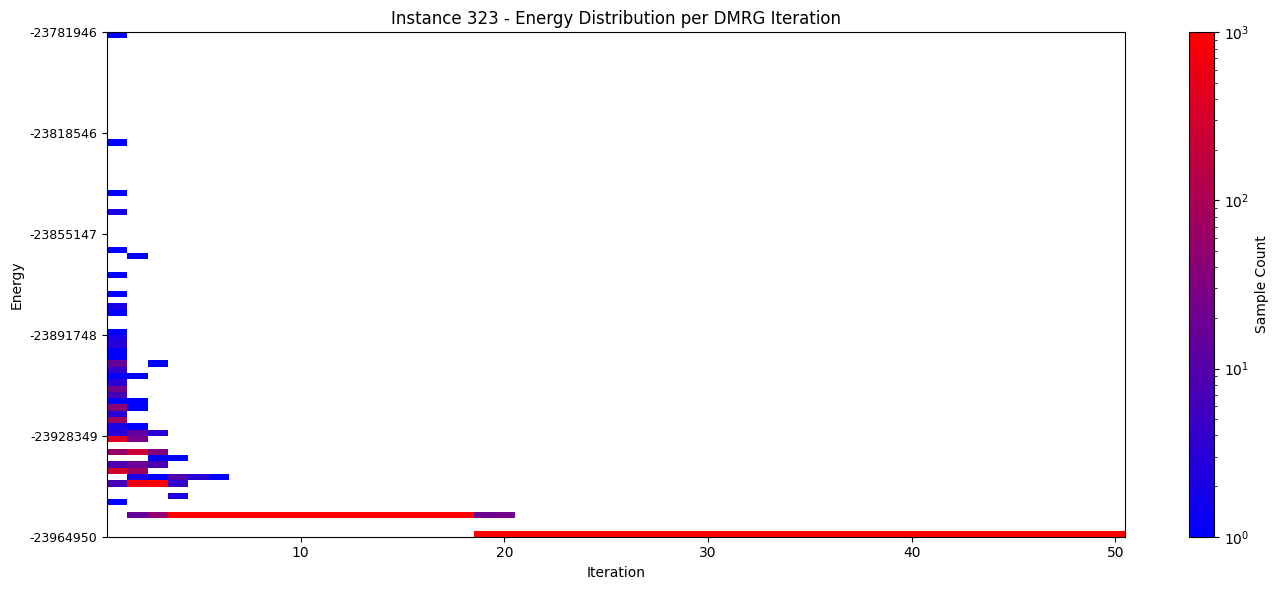

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap


def find_tensolver_dir():
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "examples" / "TenSolver"]
    for candidate in candidates:
        if (candidate / "results" / "energy_history.json").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate examples/TenSolver/results. "
        "Run this notebook from the repository root or examples/TenSolver."
    )


HERE = find_tensolver_dir()
REPO_ROOT = HERE.parents[1]
SRC_PATH = REPO_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

RANDOM_SEED = 42

with open(HERE / "results" / "energy_history.json") as f:
    all_data = json.load(f)

instance = "323"
data = all_data[instance]

iterations = [entry["iteration"] for entry in data]
all_energies = [entry["energies"] for entry in data]

n_bins = 80
all_flat = [e for energies in all_energies for e in energies]
bins = np.linspace(min(all_flat), max(all_flat), n_bins + 1)

matrix = np.array([np.histogram(energies, bins=bins)[0] for energies in all_energies]).T

blue_to_red = LinearSegmentedColormap.from_list("blue_red", ["blue", "red"])

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    matrix,
    aspect="auto",
    origin="lower",
    norm=LogNorm(vmin=1, vmax=matrix.max()),
    cmap=blue_to_red,
    interpolation="nearest",
    extent=[iterations[0] - 0.5, iterations[-1] + 0.5, bins[0], bins[-1]],
)

n_yticks = 6
ytick_vals = np.linspace(bins[0], bins[-1], n_yticks)
ax.set_yticks(ytick_vals)
ax.set_yticklabels([f"{int(v)}" for v in ytick_vals], fontsize=9)

ax.set_xlabel("Iteration")
ax.set_ylabel("Energy")
ax.set_title(f"Instance {instance} - Energy Distribution per DMRG Iteration")

fig.colorbar(im, ax=ax, label="Sample Count")

plt.tight_layout()
plt.show()


This graph shows the number of energy samples at each energy level across DMRG iterations.

There are two quantities at play: the number of iterations and the number of energy samples per iteration.
As the number of iterations increases, the number of unique energies decreases and the distribution becomes more concentrated.

Since we are interested in getting the best possible objective value while ideally minimizing work, it is only natural to question how many iterations and how many samples are sufficient for our needs.

These are the questions we will try to answer by applying Stochastic Benchmark.

## Performance Metric

To enable meaningful comparisons, we use the performance ratio as a common metric.
In this particular problem, it is calculated as follows:

- First, we sample a subset from the input space and calculate the associated energies. Specifically, we use 1000 random bitstrings.
- The mean energy across the random sample is denoted as `random`.
- We also load the best energy found by Gurobi via Branch and Bound. We denote this value as `minimum`. Note that a 900-second time limit was applied, so optimality is not guaranteed in all cases.
- The performance ratio is calculated across an increasing number of iterations, where `found` is the best energy found at the current point in the algorithm's execution.

$$
\text{performance ratio} = \frac{\text{found} - \text{random}}{\text{minimum} - \text{random}}
$$

A performance ratio of 0 means the solver did not improve over the random baseline, while a ratio of 1 means it matched Gurobi's best-known solution.

In [2]:
import json

import pandas as pd

with open(HERE / "results" / "random_baseline.json") as f:
    random_baseline_raw = json.load(f)

with open(HERE / "results" / "gurobi_best.json") as f:
    gurobi_best = json.load(f)

# Map QPLIB ID (308-330) to baselines
# random_baseline.json uses QUBOLib IDs (5808-5830), shifted by 5500
# gurobi_best.json uses QPLIB IDs (308-330) directly
baselines = {}
for qplib_id in range(308, 331):
    qubolib_key = str(qplib_id + 5500)
    qplib_key = str(qplib_id)
    if qubolib_key in random_baseline_raw and qplib_key in gurobi_best:
        rb = random_baseline_raw[qubolib_key]
        baselines[qplib_key] = {
            "random_value": rb["random_mean"],
            "best_value": gurobi_best[qplib_key]["best_objective"],
        }

rows = [
    {
        "instance": k,
        "random_mean": v["random_value"],
        "gurobi_best": v["best_value"],
    }
    for k, v in baselines.items()
]
pd.DataFrame(rows).set_index("instance")


,random_mean,gurobi_best
instance,,
308,1.006,-806
309,-0.854,-440
310,-0.024,-1686
311,-0.842,-1542
312,0.182,-1844
313,0.002,-614
314,0.980,-1142
315,0.580,-688
316,0.200,-514


## Bootstrap

Note that although we sampled 1000 energies at each iteration when solving the instances, we are interested in comparing performance across different numbers of samples.

Bootstrapping allows us to statistically infer what those distributions would look like had we solved the instances with a different number of samples.
Here we bootstrap the data for 1, 10, 100, and 1000 samples.

In [3]:
import numpy as np
import stochastic_benchmark as SB
import bootstrap
import success_metrics


class PerfRatioUnclipped(success_metrics.PerfRatio):
    def evaluate(self, bs_df, responses, resources):
        super().evaluate(bs_df, responses, resources, lower=None, upper=None)


# Load energy history (QPLIB IDs 308-330)
with open(HERE / "results" / "energy_history.json") as f:
    all_data = json.load(f)


def build_granular_df(instance_key, data):
    rows = []
    for entry in data:
        n = len(entry["energies"])
        rows.append(pd.DataFrame({
            "instance": [int(instance_key)] * n,
            "iteration": [entry["iteration"]] * n,
            "energy": entry["energies"],
            "resource": np.ones(n, dtype=int),
        }))
    return pd.concat(rows, ignore_index=True)


# Initialize stochastic_benchmark
sb = SB.stochastic_benchmark(
    parameter_names=["iteration", "samples"],
    here=str(HERE),
    instance_cols=["instance"],
    response_key="PerfRatio",
    response_dir=1,
    smooth=True,
    recover=False,
    reduce_mem=False,
)

sample_counts = [1, 10, 100, 1000]

np.random.seed(RANDOM_SEED)

# Run bootstrap per instance with hardcoded baselines to keep per-instance references explicit
bs_results = []
for inst_key, data in all_data.items():
    if inst_key not in baselines or data is None:
        continue

    inst_df = build_granular_df(inst_key, data)
    baseline = baselines[inst_key]

    bsParams = bootstrap.BootstrapParameters(
        shared_args={
            "response_col": "energy",
            "resource_col": "resource",
            "random_value": baseline["random_value"],
            "best_value": baseline["best_value"],
            "confidence_level": 68,
        },
        metric_args={"Response": {"opt_sense": -1}},
        success_metrics=[success_metrics.Response, PerfRatioUnclipped],
        bootstrap_iterations=1000,
        update_rule=lambda bs_params, df: None,
    )

    bsParams_iter = bootstrap.BSParams_range_iter()(bsParams, sample_counts)
    bs_inst = bootstrap.Bootstrap(
        inst_df,
        group_on=["instance", "iteration"],
        bs_params_list=bsParams_iter,
    )
    bs_results.append(bs_inst)

bs_df = pd.concat(bs_results, ignore_index=True)
bs_df["samples"] = bs_df["boots"]

sb.set_Bootstrap(bs_df)

bs_df.head()


,instance,iteration,Key=Response,ConfInt=lower_Key=Response,ConfInt=upper_Key=Response,Key=PerfRatio,ConfInt=lower_Key=PerfRatio,ConfInt=upper_Key=PerfRatio,boots,samples
0,308,1,-656.540,-662.097267,-650.982733,0.814797,0.807911,0.821683,1,1
1,308,2,-691.914,-692.354943,-691.473057,0.858631,0.858084,0.859177,1,1
2,308,3,-718.004,-718.753470,-717.254530,0.890960,0.890031,0.891889,1,1
3,308,4,-722.026,-722.251292,-721.800708,0.895944,0.895665,0.896223,1,1
4,308,5,-724.000,-724.000000,-724.000000,0.898390,0.898390,0.898390,1,1


## Resource Proxy for Time

Given the quantities we are studying (number of iterations and number of samples), we need to define the resource we are interested in minimizing.
In this case, we can use `iterations × samples` as a proxy for the running time of the algorithm.

The reason we will not use the recorded wall-clock time directly is that it varies across runs and computing environments.
For our objective of finding better combinations of parameters, it is useful to work with more stable metrics.

In [4]:
import interpolate

def resource_fcn(df):
    return df["iteration"] * df["samples"]

iParams = interpolate.InterpolationParameters(resource_fcn, parameters=["iteration", "samples"])
sb.run_Interpolate(iParams)

if sb.interp_results.index.names[0] is not None:
    sb.interp_results.reset_index(inplace=True)
    sb.interp_results.to_pickle(sb.here.interpolate)


## Initial Investigation

In [5]:
# Performance ratio range for instance 326 across sample counts
inst_df = bs_df[bs_df["instance"] == 326]
perf_col = "Key=PerfRatio"

def find_iter_at(df, fn):
    val = fn(df[perf_col])
    return df[df[perf_col] == val]["iteration"].values[0], float(val)

print(f"Instance 326  (n=200 variables)")
print(f"{'Samples':<12}|{'Min PerfRatio':<18}|{'At Iter':<10}|{'Max PerfRatio':<18}|{'At Iter':<10}")
print("-"*12 + "|" + "-"*18 + "|" + "-"*10 + "|" + "-"*18 + "|" + "-"*10)
for n_samp in [1, 10, 100, 1000]:
    df = inst_df[inst_df["samples"] == n_samp]
    min_iter, min_val = find_iter_at(df, min)
    max_iter, max_val = find_iter_at(df, max)
    print(f"{n_samp:<12}|{min_val:<18.4f}|{min_iter:<10}|{max_val:<18.4f}|{max_iter:<10}")
    print("-"*12 + "|" + "-"*18 + "|" + "-"*10 + "|" + "-"*18 + "|" + "-"*10)


Instance 326  (n=200 variables)
Samples     |Min PerfRatio     |At Iter   |Max PerfRatio     |At Iter   
------------|------------------|----------|------------------|----------
1           |0.9406            |1         |0.9885            |45        
------------|------------------|----------|------------------|----------
10          |0.9469            |1         |0.9885            |40        
------------|------------------|----------|------------------|----------
100         |0.9493            |1         |0.9885            |38        
------------|------------------|----------|------------------|----------
1000        |0.9504            |1         |0.9885            |35        
------------|------------------|----------|------------------|----------


This basic overview reveals two key observations:
- Increasing the number of samples does not yield better objective values by the final iteration, which makes sense since the energy distribution converges to a single value by the end.
- Increasing the number of samples does help achieve better values in fewer iterations, but does not reduce the required iteration count by an order of magnitude or more. In other words, the reduction in iterations does not justify the increase in the number of samples.

Overall, this indicates that using a small number of samples is the better option, but it does not answer all of our questions:

- How should the parameters be distributed given a fixed resource budget?
- How close to the virtual best does a given resource budget get us?

These questions will be answered by the complete framework evaluation.

In [6]:
import stats

train_test_split = 0.8
stParams = stats.StatsParameters(metrics=["PerfRatio"], stats_measures=[stats.Median()])

np.random.seed(RANDOM_SEED)
sb.run_Stats(stParams, train_test_split)

sb.run_baseline()

sb.run_ProjectionExperiment("TrainingStats", None, None)
sb.run_ProjectionExperiment("TrainingResults", None, None)


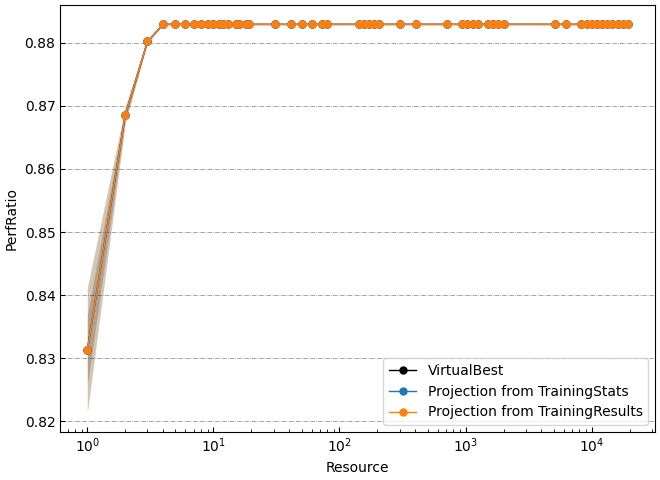

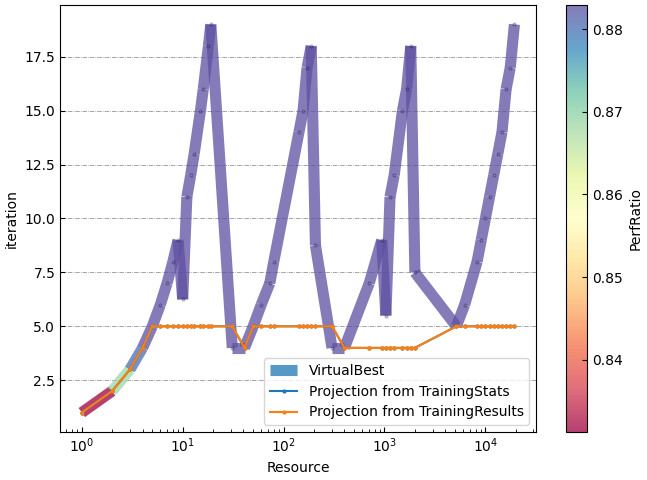

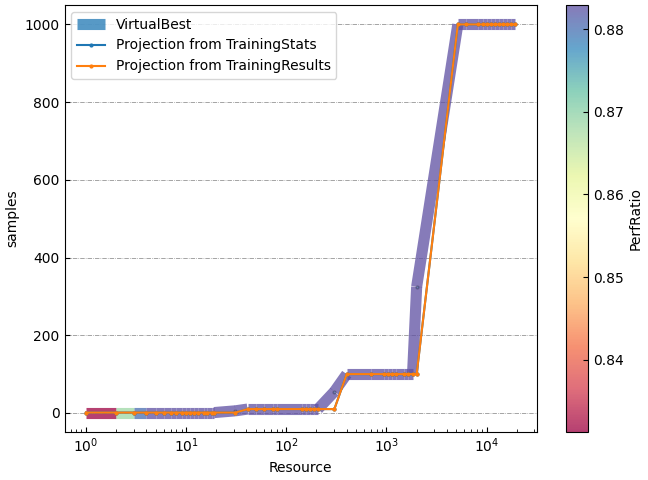

In [7]:
import plotting

plotting.monotone = True
sb.initPlotting()

fig, axs = sb.plots.plot_performance()
fig.savefig(HERE / "performance.png")

figs, axes = sb.plots.plot_parameters_separate()
for param, fig in figs.items():
    fig.savefig(HERE / f"{param}.png")


## Conclusion


In general, it is better to invest fewer resources in samples while aiming for a reasonable number of iterations. This is consistent with the initial investigation.
The initial investigation indicated that the best achievable performance ratio could be reached with one sample per iteration and around 45 iterations, corresponding to a resource value of 45.

However, the input recommendation plot shows a jump in performance at a much lower resource value, around 10, which translates to 1 sample and 10 iterations.
This does not correspond to peak performance, but it is clear that performance does not improve significantly beyond this point, making this a good operating point for the samples-versus-iterations trade-off.

## References

[1] Andrew Lucas. Ising formulations of many NP problems. Frontiers in Physics, 2, 2014.
[2] I. V. Oseledets. Tensor-Train Decomposition. SIAM Journal on Scientific Computing,
33(5):2295–2317, 2011. _eprint: https://doi.org/10.1137/090752286.
[3] Steven R. White. Density matrix formulation for quantum renormalization groups. Phys. Rev.
Lett., 69:2863–2866, Nov 1992.
[4] Steven R. White. Density-matrix algorithms for quantum renormalization groups. Phys. Rev. B,
48:10345–10356, Oct 1993.
[5] Matthew Fishman, Steven R. White, and E. Miles Stoudenmire. Codebase release 0.3 for
ITensor. SciPost Phys. Codebases, pages 4–r0.3, 2022.
[6] Pedro Maciel Xavier and David E. Bernal Neira. QUBOLib.jl: A Julia library of QUBO
instances, 2023. Accessed: 2025-11-21.
[7] Fabio Furini, Emiliano Traversi, Pietro Belotti, Antonio Frangioni, Ambros Gleixner, Nick
Gould, Leo Liberti, Andrea Lodi, Ruth Misener, Hans Mittelmann, Nikolaos Sahinidis, Stefan
Vigerske, and Angelika Wiegele. QPLIB: A library of quadratic programming instances.
Mathematical Programming Computation, 2018.